In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    f1_score,ConfusionMatrixDisplay, roc_curve
)
import joblib


warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

DATA_DIR = Path('../data')
MODEL_DIR = Path('../models')
MODEL_DIR.mkdir(exist_ok=True)

In [2]:
plus_files = sorted(DATA_DIR.glob('*_plus.csv'))
print(f"Found {len(plus_files)} files _plus:")
for f in plus_files:
    print(f"{f.name} ({f.stat().st_size / 1024**2:.1f} MB)")

def load_file(path,sample_frac = 1.0,random_state = 42):
    df = pd.read_csv(path,low_memory=False)
    df.columns = df.columns.str.strip()
    df.replace([np.inf, -np.inf], np.nan,inplace=True)
    if sample_frac < 1.0:
        df = df.sample(frac=sample_frac, random_state=random_state)
    return df

chunks = []
for f in plus_files:
    print(f"Loading {f.name}...",end=' ')
    chunk = load_file(f,sample_frac=1.0)
    chunks.append(chunk)
    print(f"{len(chunk):,} rows | labels: {chunk['Label'].unique()}")

df = pd.concat(chunks,ignore_index=True)
print(f"\n Total: {len(df):,} rows, {df.shape[1]} cols")

Found 5 files _plus:
friday_plus.csv (232.9 MB)
monday_plus.csv (166.4 MB)
thursday_plus.csv (153.6 MB)
tuesday_plus.csv (142.4 MB)
wednesday_plus.csv (235.0 MB)
Loading friday_plus.csv... 547,557 rows | labels: <StringArray>
['BENIGN', 'Botnet - Attempted', 'Botnet', 'Portscan', 'DDoS']
Length: 5, dtype: str
Loading monday_plus.csv... 371,621 rows | labels: <StringArray>
['BENIGN']
Length: 1, dtype: str
Loading thursday_plus.csv... 362,075 rows | labels: <StringArray>
[                                'BENIGN',
   'Web Attack - Brute Force - Attempted',
               'Web Attack - Brute Force',
               'Infiltration - Attempted',
                           'Infiltration',
                'Infiltration - Portscan',
           'Web Attack - XSS - Attempted',
                       'Web Attack - XSS',
 'Web Attack - SQL Injection - Attempted',
             'Web Attack - SQL Injection']
Length: 10, dtype: str
Loading tuesday_plus.csv... 322,078 rows | labels: <StringArray>
[       

Class Decomposition:
Label
BENIGN                                    1582561
Portscan                                   159066
DoS Hulk                                   158468
DDoS                                        95144
Infiltration - Portscan                     71767
DoS GoldenEye                                7567
Botnet - Attempted                           4067
FTP-Patator                                  3972
DoS Slowloris                                3859
DoS Slowhttptest - Attempted                 3368
SSH-Patator                                  2961
DoS Slowloris - Attempted                    1847
DoS Slowhttptest                             1740
Web Attack - Brute Force - Attempted         1292
Botnet                                        736
Web Attack - XSS - Attempted                  655
DoS Hulk - Attempted                          581
DoS GoldenEye - Attempted                      80
Web Attack - Brute Force                       73
Infiltration - Attempte

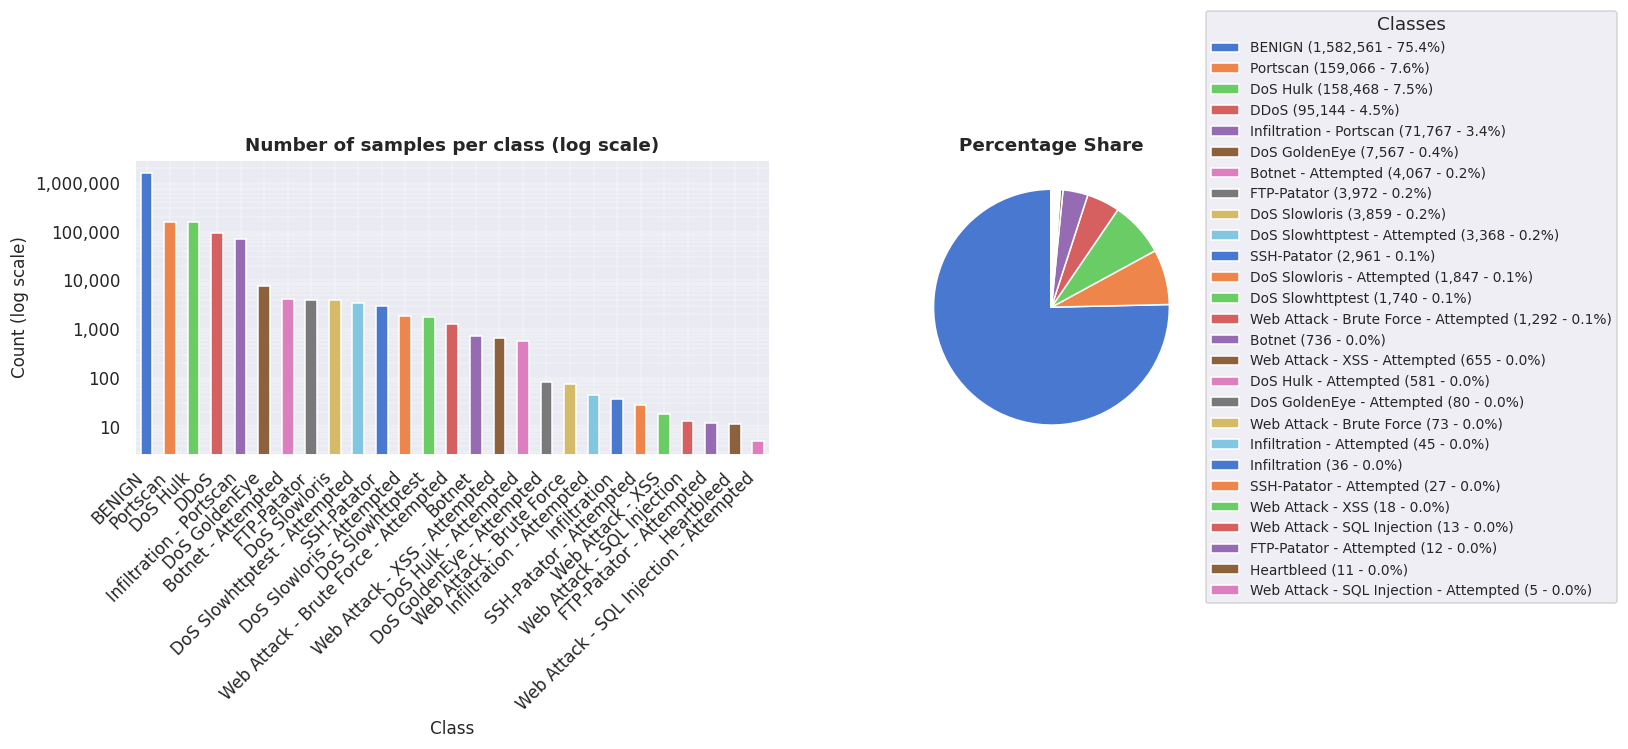

In [3]:
label_counts = df['Label'].value_counts()
print("Class Decomposition:")
print(label_counts.to_string())

fig,axes = plt.subplots(1,2,figsize=(16,6))

label_counts.plot(kind ='bar', ax=axes[0],
                  color = sns.color_palette('muted',len(label_counts)))
axes[0].set_title('Number of samples per class (log scale)', fontsize=12, fontweight='bold')
axes[0].set_xlabel("Class", fontsize=11)
axes[0].set_ylabel("Count (log scale)", fontsize=11)
axes[0].set_yscale('log')
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x,_: f'{int(x):,}')
)
plt.setp(axes[0].get_xticklabels(),rotation = 45,ha='right')
axes[0].grid(True, which='both', alpha=0.3)

colors = sns.color_palette('muted',len(label_counts))
wedges, texts = axes[1].pie(label_counts, 
                             startangle=90, 
                             colors=colors)
axes[1].set_title("Percentage Share", fontsize=12, fontweight='bold')
axes[1].legend(wedges, 
               [f'{label} ({count:,} - {count/len(df)*100:.1f}%)' 
                for label, count in label_counts.items()], 
               title="Classes",
               loc="center left",
               bbox_to_anchor=(1, 0, 0.5, 1),
               fontsize=9)

plt.tight_layout()
plt.savefig(MODEL_DIR / 'fig_label_distribution.png',bbox_inches = 'tight', dpi=150)
plt.show()

In [4]:
# metadane - do odrzucenia
DROP_COLS = [
    'Flow ID', 'Timestamp',
    'Src IP dec', 'Local', *[f'Local_{i}' for i in range(1,15)], #local_1..local_14
    'Attempted Category'] # numeryczna wersja label - target leakage

drop_exsisting = [c for c in DROP_COLS if c in df.columns]
df.drop(columns = drop_exsisting,inplace = True)
print(f"Removed {len(drop_exsisting)} metadata columns")

df.fillna(df.select_dtypes(include=[np.number]).median(),inplace=True)

num_cols = df.select_dtypes(include=[np.number]).columns
zero_var = [c for c in num_cols if df[c].std() == 0]
df.drop(columns=zero_var,inplace=True)
print(f"Dropped {len(zero_var)} columns with zero variation: {zero_var}")
print(f"Columns after cleaning: {df.shape[1]}")

Removed 19 metadata columns
Dropped 0 columns with zero variation: []
Columns after cleaning: 86


In [5]:
le = LabelEncoder()
y = le.fit_transform(df['Label'])
y_binary = (df['Label'] != 'BENIGN').astype(int).values

print("Class mapping: ")
for i,cls in enumerate(le.classes_):
    count = (df["Label"] == cls).sum()
    print(f" {i:2d} {cls:40s} {count:,}")

joblib.dump(le,MODEL_DIR / "label_encoder.pkl",compress=3)

exclude = ['Label', 'Src Port', 'Dst Port','Protocol']

feature_cols = [c for c in df.select_dtypes(include=np.number).columns
                if c not in exclude]

X = df[feature_cols].values

print(f"\nAtribiute: {len(feature_cols)}")
joblib.dump(feature_cols, MODEL_DIR / 'feature_columns.pkl',compress=3)


X_train, X_test, y_train,y_test, yb_train,yb_test = train_test_split(X,
                        y,y_binary,test_size=0.2,random_state=42,stratify=y)

print(f"Trening: {len(X_train):,} | Test: {len(X_test):,}")




Class mapping: 
  0 BENIGN                                   1,582,561
  1 Botnet                                   736
  2 Botnet - Attempted                       4,067
  3 DDoS                                     95,144
  4 DoS GoldenEye                            7,567
  5 DoS GoldenEye - Attempted                80
  6 DoS Hulk                                 158,468
  7 DoS Hulk - Attempted                     581
  8 DoS Slowhttptest                         1,740
  9 DoS Slowhttptest - Attempted             3,368
 10 DoS Slowloris                            3,859
 11 DoS Slowloris - Attempted                1,847
 12 FTP-Patator                              3,972
 13 FTP-Patator - Attempted                  12
 14 Heartbleed                               11
 15 Infiltration                             36
 16 Infiltration - Attempted                 45
 17 Infiltration - Portscan                  71,767
 18 Portscan                                 159,066
 19 SSH-Patator         

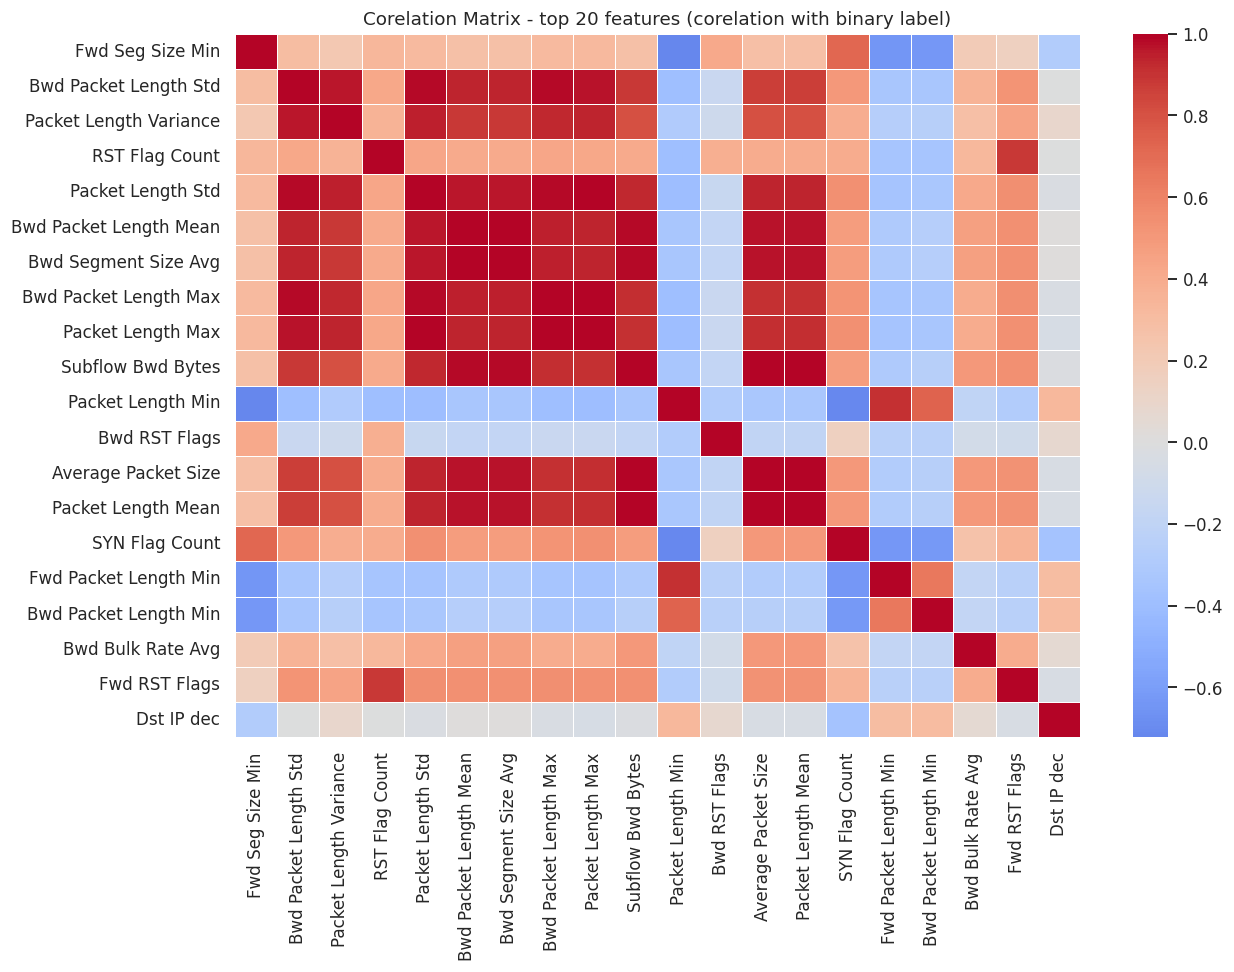

In [6]:
df_corr = pd.DataFrame(X_train[:20_000],columns=feature_cols)
binary_ser = pd.Series(yb_train[:20_000])

target_corr = df_corr.corrwith(binary_ser).abs().sort_values(ascending=False)
top20 = target_corr.head(20).index.tolist()

fig,ax = plt.subplots(figsize = (12,9))
sns.heatmap(df_corr[top20].corr(), cmap='coolwarm',center=0,
            linewidths=0.4,ax=ax,annot=False)
ax.set_title("Corelation Matrix - top 20 features (corelation with binary label)")
plt.tight_layout()
plt.savefig(MODEL_DIR / 'fig_corelation_matrix.png',bbox_inches = 'tight')
plt.show()



In [7]:
print("Random Forest Training(multiclass)... ")
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=5,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train,y_train)
print("Ready")

Random Forest Training(multiclass)... 
Ready


                                        precision    recall  f1-score   support

                                BENIGN       1.00      1.00      1.00    316513
                                Botnet       1.00      1.00      1.00       147
                    Botnet - Attempted       0.99      0.98      0.98       813
                                  DDoS       1.00      1.00      1.00     19029
                         DoS GoldenEye       1.00      1.00      1.00      1514
             DoS GoldenEye - Attempted       1.00      1.00      1.00        16
                              DoS Hulk       1.00      1.00      1.00     31694
                  DoS Hulk - Attempted       0.97      1.00      0.98       116
                      DoS Slowhttptest       0.99      0.99      0.99       348
          DoS Slowhttptest - Attempted       0.98      0.99      0.99       674
                         DoS Slowloris       1.00      1.00      1.00       772
             DoS Slowloris - Attempted 

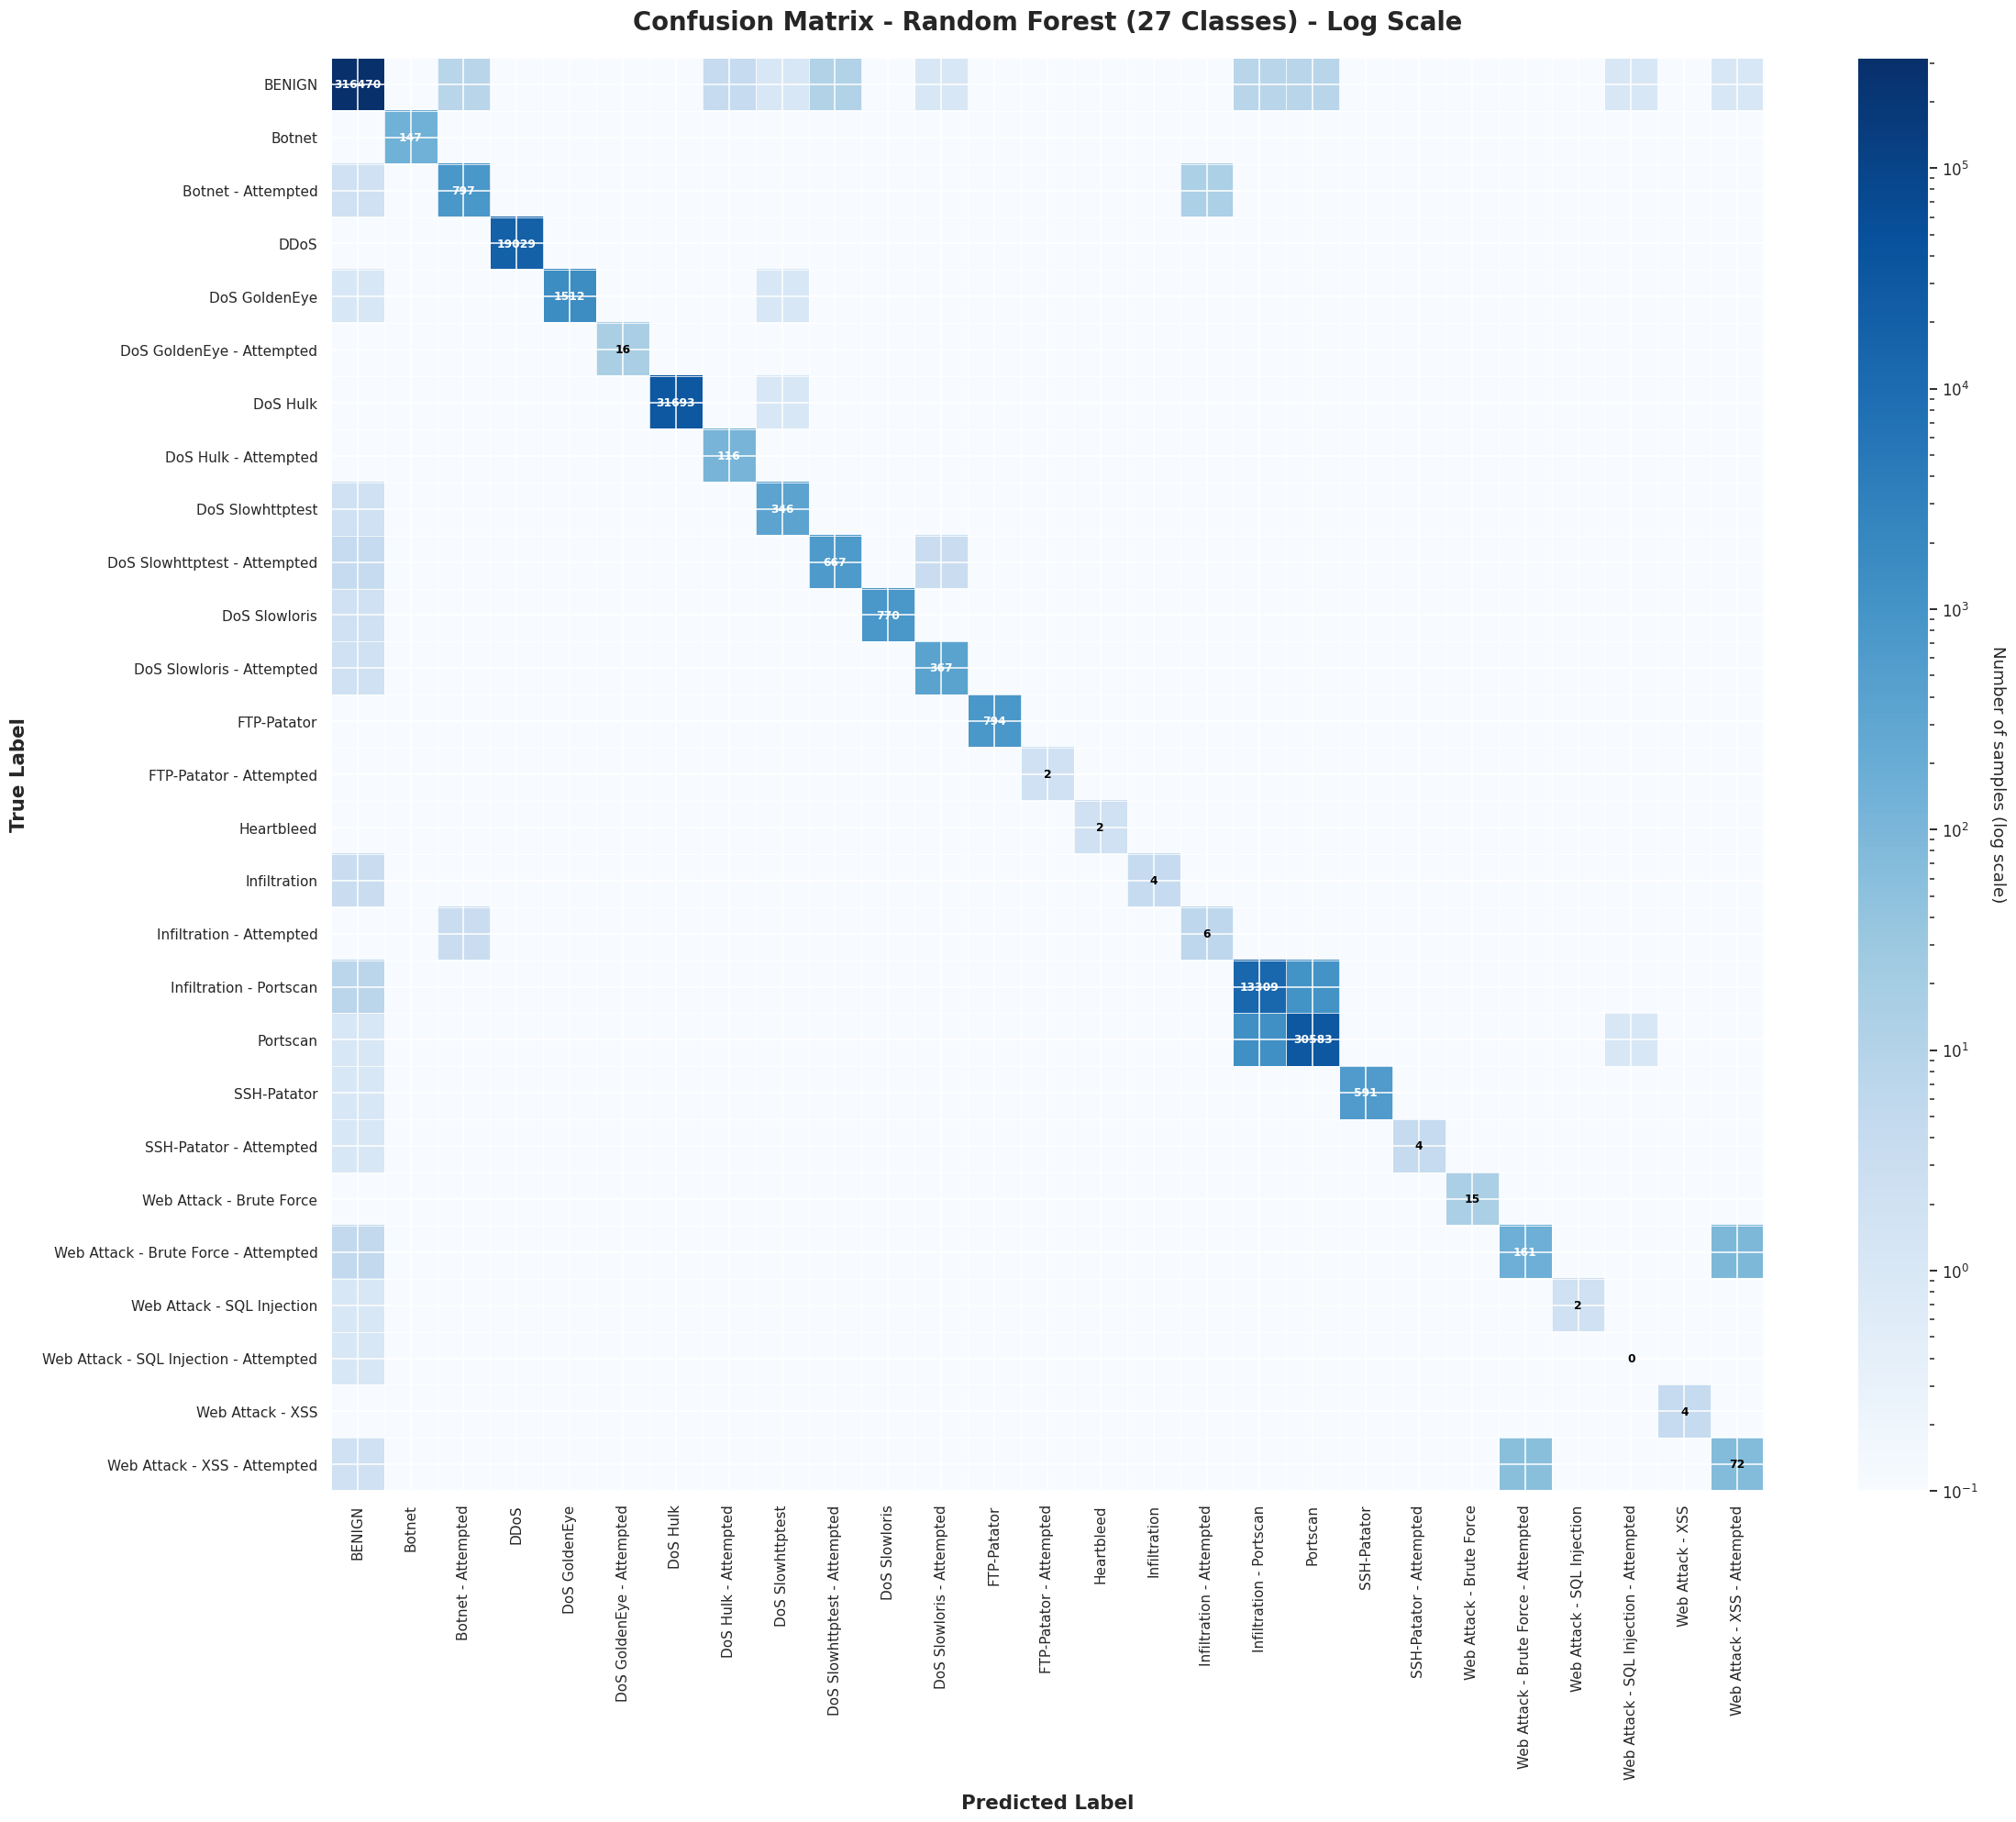

In [8]:
y_pred = rf.predict(X_test)
print(classification_report(y_test,y_pred,target_names=le.classes_,zero_division=0))
f1 = f1_score(y_test,y_pred,average='weighted',zero_division=0)
print(f"Weighted F1: {f1:.4f}")

cm = confusion_matrix(y_test,y_pred)

from matplotlib.colors import LogNorm

fig, ax = plt.subplots(figsize=(22, 18))
cm_plot = np.where(cm > 0, cm, 0.1)


im = ax.imshow(cm_plot, interpolation='nearest', cmap='Blues', 
               norm=LogNorm(vmin=cm_plot.min(), vmax=cm_plot.max()))
cbar = plt.colorbar(im, ax=ax)
cbar.ax.tick_params(labelsize=11)
cbar.set_label('Number of samples (log scale)', rotation=270, labelpad=20, fontsize=12)

for i in range(len(le.classes_)):
    text = ax.text(i, i, str(cm[i, i]),
                   ha="center", va="center", color="white" if cm[i, i] > 100 else "black",
                   fontsize=8, fontweight='bold')


tick_marks = np.arange(len(le.classes_))
ax.set_xticks(tick_marks)
ax.set_yticks(tick_marks)
ax.set_xticklabels(le.classes_, rotation=90, ha='center', fontsize=10)
ax.set_yticklabels(le.classes_, fontsize=10)

ax.set_title('Confusion Matrix - Random Forest (27 Classes) - Log Scale', 
             fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Predicted Label', fontsize=14, fontweight='bold', labelpad=10)
ax.set_ylabel('True Label', fontsize=14, fontweight='bold', labelpad=10)

ax.set_xticks(tick_marks - 0.5, minor=True)
ax.set_yticks(tick_marks - 0.5, minor=True)
ax.grid(which='minor', color='white', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.savefig(MODEL_DIR / 'fig_confusion_matrix.png', bbox_inches='tight', dpi=300)
plt.show()

In [13]:
rf_bin = RandomForestClassifier(
    n_estimators=150,max_depth=15,
    class_weight='balanced',n_jobs=-1,random_state=42
)
rf_bin.fit(X_train, yb_train)
yb_prob = rf_bin.predict_proba(X=X_test)[:, 1]

fpr, tpr, _ = roc_curve(yb_test,yb_prob)
auc = roc_auc_score(yb_test,yb_prob)


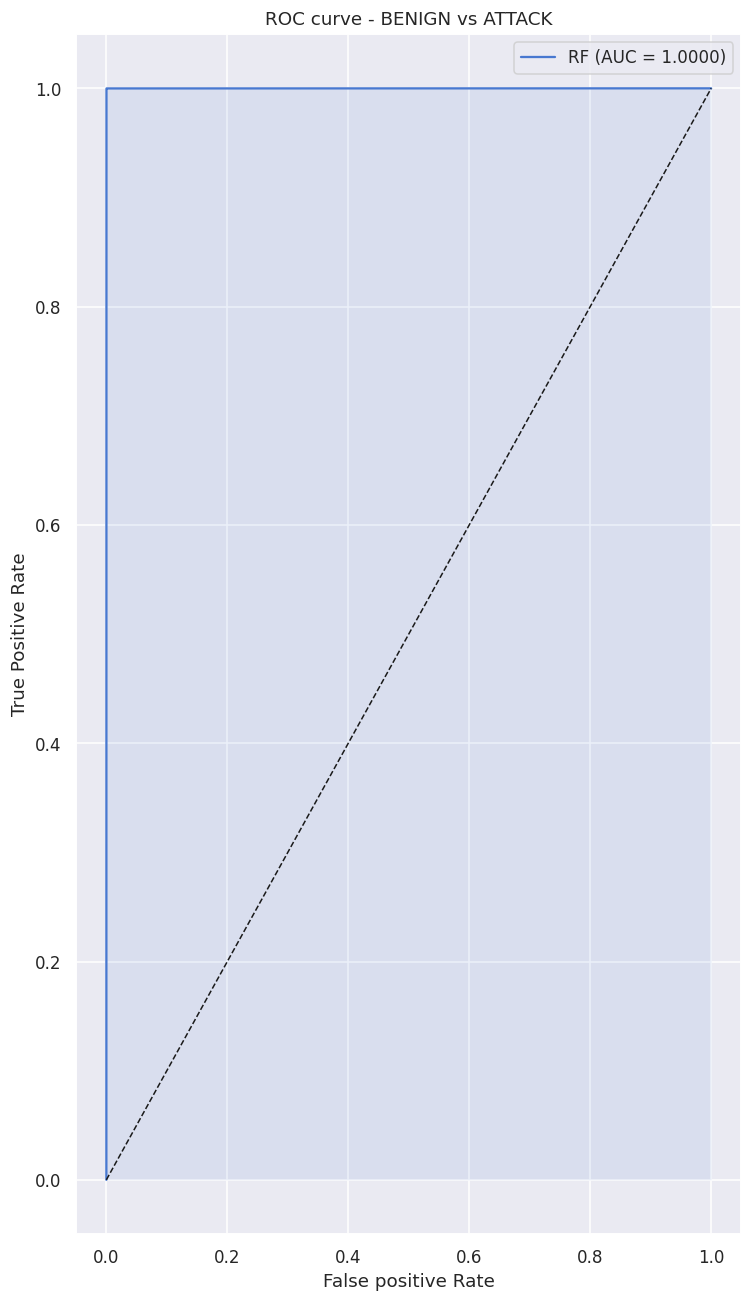

ROC-AUC: 1.0000

 Models saved: 
feature_columns.pkl                      1 KB
fig_confusion_matrix.png                 779 KB
fig_corelation_matrix.png                139 KB
fig_label_distribution.png               453 KB
fig_roc_curve.png                        48 KB
label_encoder.pkl                        1 KB
model_binary.pkl                         3344 KB
model_multiclass.pkl                     13320 KB


In [28]:
fig, ax = plt.subplots(figsize = (7,12))
ax.plot(fpr,tpr,label = f"RF (AUC = {auc:.4f})")
ax.plot([0,1],[0,1], "k--",lw=1)
ax.fill_between(fpr,tpr,alpha = .1)
ax.set_xlabel("False positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC curve - BENIGN vs ATTACK")
ax.legend()
plt.tight_layout()
plt.savefig(MODEL_DIR / 'fig_roc_curve.png', bbox_inches = 'tight')
plt.show()
print(f"ROC-AUC: {auc:.4f}")

joblib.dump(rf, MODEL_DIR / 'model_multiclass.pkl', compress= 3)
joblib.dump(rf_bin, MODEL_DIR / 'model_binary.pkl', compress=3)
print("\n Models saved: ")
for f in sorted(MODEL_DIR.iterdir()):
    print(f"{f.name:40s} {f.stat().st_size/1024:.0f} KB")

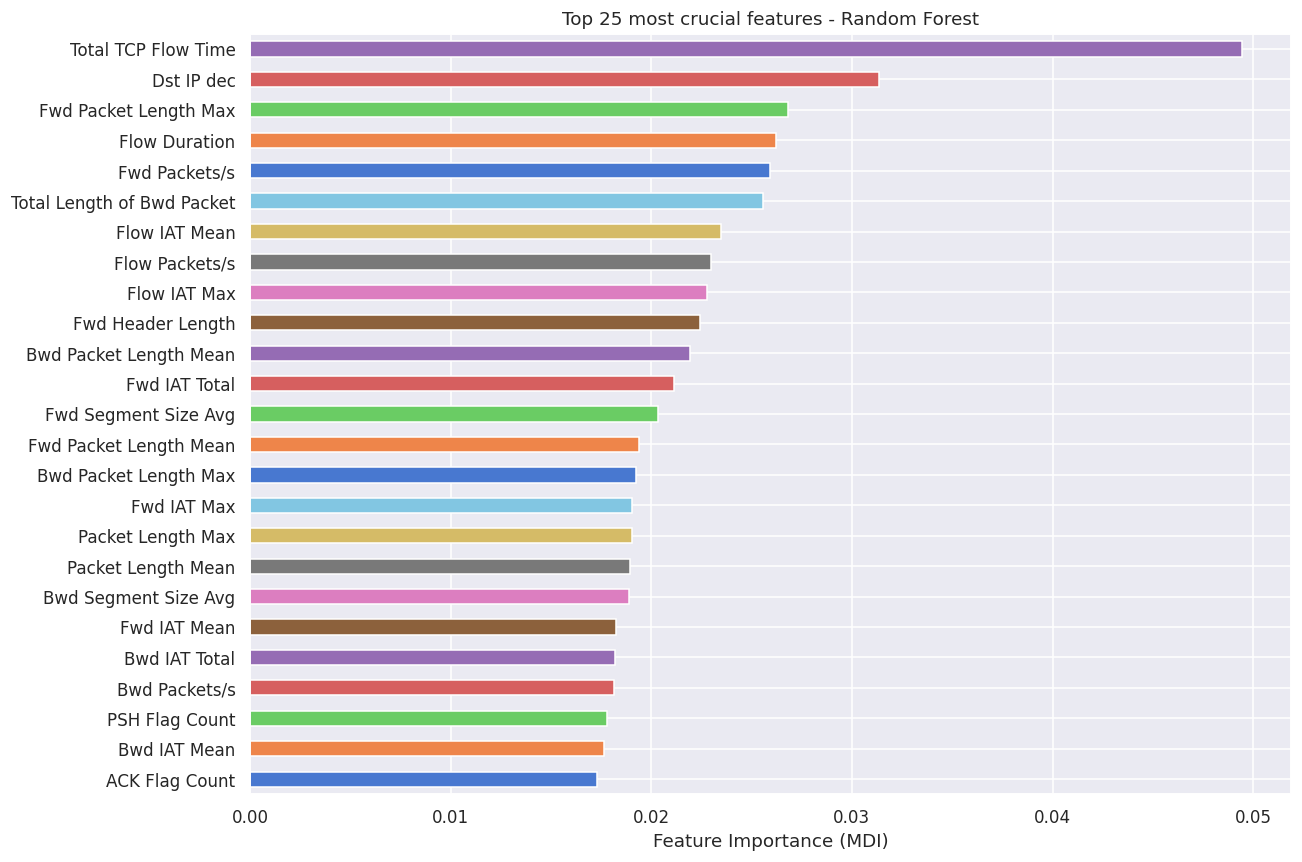

TOP 10:
Total TCP Flow Time           0.049435
Dst IP dec                    0.031348
Fwd Packet Length Max         0.026791
Flow Duration                 0.026211
Fwd Packets/s                 0.025905
Total Length of Bwd Packet    0.025566
Flow IAT Mean                 0.023477
Flow Packets/s                0.022977
Flow IAT Max                  0.022790
Fwd Header Length             0.022435


In [43]:
imp = pd.Series(rf.feature_importances_,index=feature_cols)
top25 = imp.sort_values(ascending=False).head(25)


fig, ax = plt.subplots(figsize = (12,8))
top25[::-1].plot(kind = 'barh', ax = ax, color = sns.color_palette('muted', 25))
ax.set_title("Top 25 most crucial features - Random Forest")
ax.set_xlabel('Feature Importance (MDI)')
plt.tight_layout()
plt.savefig( MODEL_DIR / 'fig_feature_importance.png',bbox_inches = 'tight')
plt.show()

print("TOP 10:")
print(top25.head(10).to_string())